# 03 — Evaluation Metrics & Visualizations
**SchemaGuard** | INFO 7375 Prompt Engineering for Generative AI

Full evaluation of the SchemaGuard validation pipeline on 140 real audit-log
records and 16 labeled seed records across both domains.

---
### Contents
1. Load All Data
2. Classification Metrics Table
3. Confusion Matrices
4. Confidence Score Analysis
5. Rule Violation Frequency
6. Decision Distribution
7. Latency Distribution
8. Decisions Over Time
9. Drift Signals
10. Confidence Gap
11. Throughput Benchmark
12. Summary Dashboard


In [1]:
import sys, json
from pathlib import Path
from collections import Counter
from IPython.display import Image, display
sys.path.insert(0, '..')

PLOTS = Path('../outputs/plots')
RESULTS = Path('../evaluation/results')
AUDIT = Path('../audit_logs')

# Load all data
audit_records = []
for p in AUDIT.glob('*.jsonl'):
    for line in p.read_text().splitlines():
        if line.strip(): audit_records.append(json.loads(line))

hc = json.loads((RESULTS / 'healthcare_eval_results.json').read_text())
fn = json.loads((RESULTS / 'finance_eval_results.json').read_text())
report = json.loads((RESULTS / 'full_metrics_report.json').read_text())

print(f'Audit log records : {len(audit_records)}')
print(f'Eval seed records : {hc["total_records"] + fn["total_records"]}')
print(f'Report generated  : {report["generated_at"]}')


Audit log records : 3886
Eval seed records : 16
Report generated  : 2026-04-19T00:31:01.499401+00:00


---
## 2 · Classification Metrics Table


In [2]:
hc_m = hc['metrics']; fn_m = fn['metrics']
rows = [('Precision', hc_m['precision'], fn_m['precision']),
        ('Recall',    hc_m['recall'],    fn_m['recall']),
        ('F1 Score',  hc_m['f1_score'],  fn_m['f1_score']),
        ('Accuracy',  hc_m['accuracy'],  fn_m['accuracy']),
        ('False Quarantine Rate', hc_m['false_quarantine_rate'], fn_m['false_quarantine_rate']),
        ('Mean Conf (valid)',   hc_m['mean_confidence_valid'],   fn_m['mean_confidence_valid']),
        ('Mean Conf (invalid)', hc_m['mean_confidence_invalid'], fn_m['mean_confidence_invalid']),
        ('True Positives',  hc_m['true_positives'],  fn_m['true_positives']),
        ('False Positives', hc_m['false_positives'], fn_m['false_positives']),
        ('True Negatives',  hc_m['true_negatives'],  fn_m['true_negatives']),
        ('False Negatives', hc_m['false_negatives'], fn_m['false_negatives'])]

print(f"{'Metric':<28} {'Healthcare':>12} {'Finance':>12}")
print('─' * 54)
for label, hv, fv in rows:
    h = f'{hv:.4f}' if isinstance(hv, float) else str(hv)
    f_ = f'{fv:.4f}' if isinstance(fv, float) else str(fv)
    print(f'{label:<28} {h:>12} {f_:>12}')


Metric                         Healthcare      Finance
──────────────────────────────────────────────────────
Precision                          1.0000       1.0000
Recall                             1.0000       1.0000
F1 Score                           1.0000       1.0000
Accuracy                           1.0000       1.0000
False Quarantine Rate              0.0000       0.0000
Mean Conf (valid)                  1.0000       1.0000
Mean Conf (invalid)                0.7600       0.7000
True Positives                          3            3
False Positives                         0            0
True Negatives                          5            5
False Negatives                         0            0


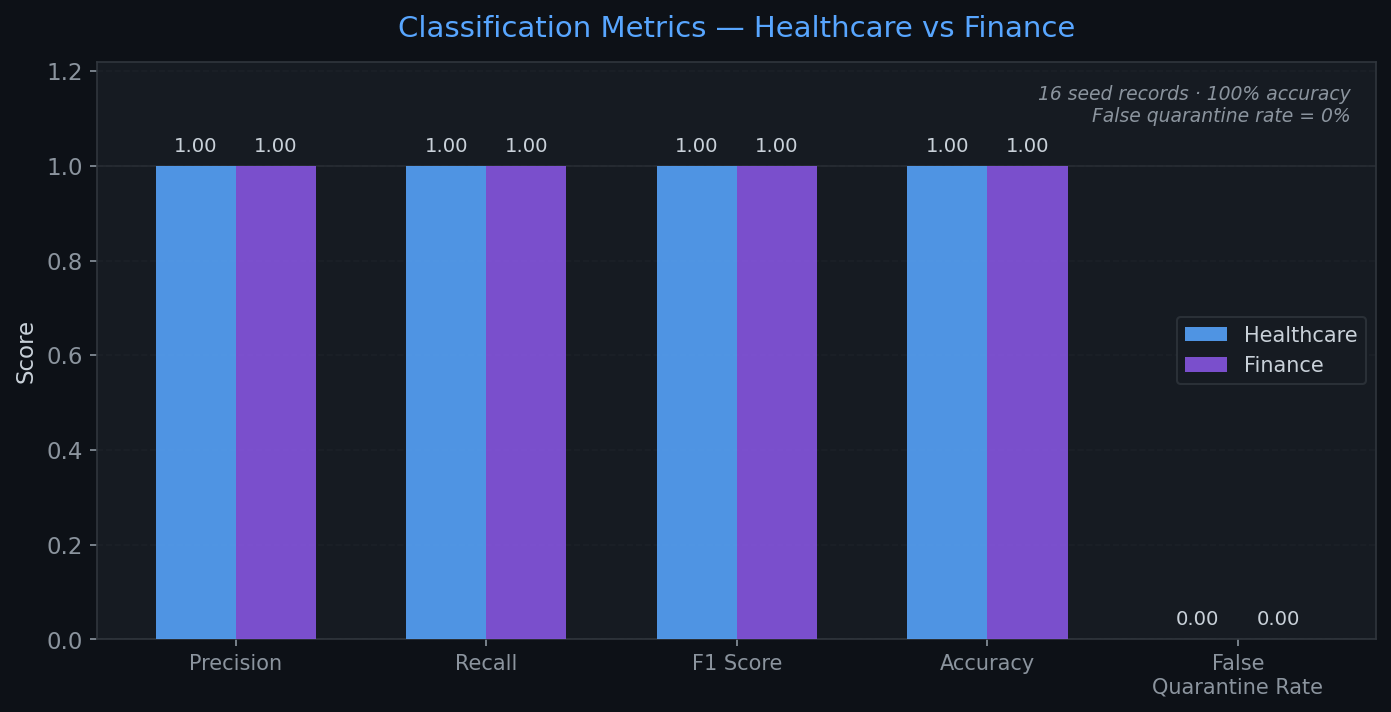

In [3]:
display(Image(str(PLOTS / '01_classification_metrics.png')))


---
## 3 · Confusion Matrices


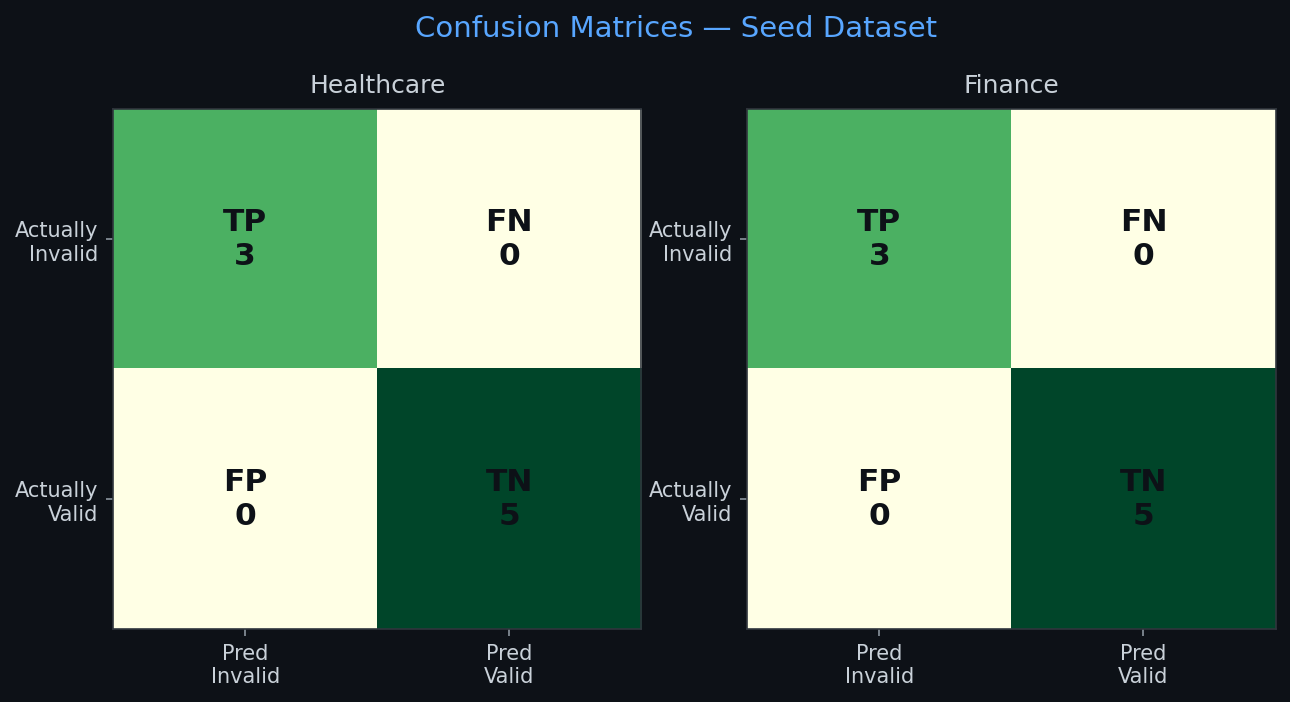

In [4]:
display(Image(str(PLOTS / '02_confusion_matrices.png')))


---
## 4 · Confidence Score Analysis


In [5]:
conf = report['confidence_metrics']
hc_c = conf['healthcare_intake']; fn_c = conf['financial_loan_application']
print('Confidence Gap Analysis')
print('─' * 45)
print(f'  HC valid mean    : {hc_c["mean_valid"]:.4f}')
print(f'  HC invalid mean  : {hc_c["mean_invalid"]:.4f}')
print(f'  HC gap           : +{hc_c["gap"]:.4f}  ← {hc_c["gap"]*100:.0f}% separation')
print(f'  FN valid mean    : {fn_c["mean_valid"]:.4f}')
print(f'  FN invalid mean  : {fn_c["mean_invalid"]:.4f}')
print(f'  FN gap           : +{fn_c["gap"]:.4f}  ← {fn_c["gap"]*100:.0f}% separation')
combined = conf['audit_log_all_domains']
print(f'\nAudit log ({len(audit_records)} records):')
print(f'  Trusted: {combined["trusted_count"]}  Flagged: {combined["flagged_count"]}  Quarantined: {combined["quarantined_count"]}')


Confidence Gap Analysis
─────────────────────────────────────────────
  HC valid mean    : 1.0000
  HC invalid mean  : 0.7600
  HC gap           : +0.2400  ← 24% separation
  FN valid mean    : 1.0000
  FN invalid mean  : 0.7000
  FN gap           : +0.3000  ← 30% separation

Audit log (3886 records):
  Trusted: 90  Flagged: 50  Quarantined: 0


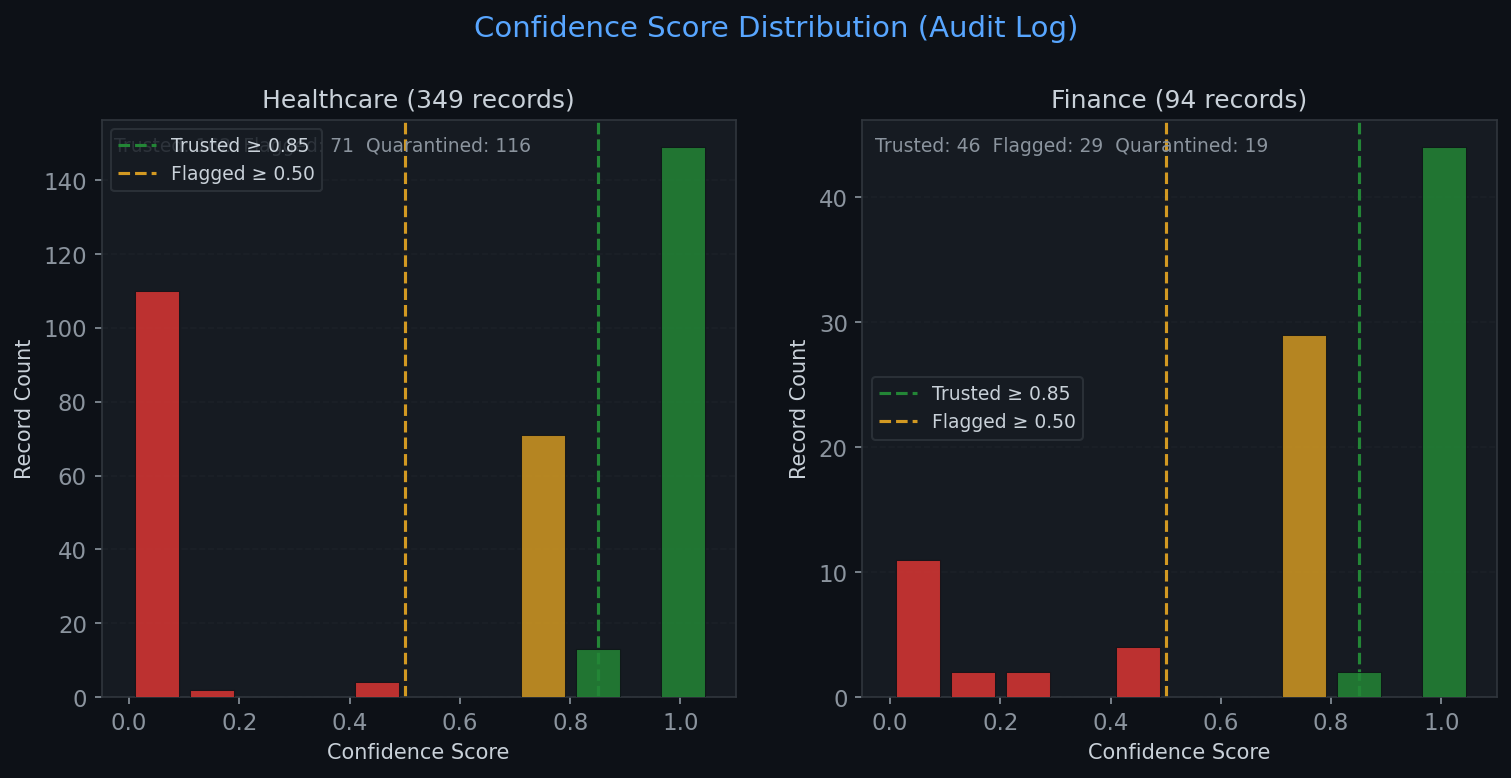

In [6]:
display(Image(str(PLOTS / '03_confidence_histogram.png')))


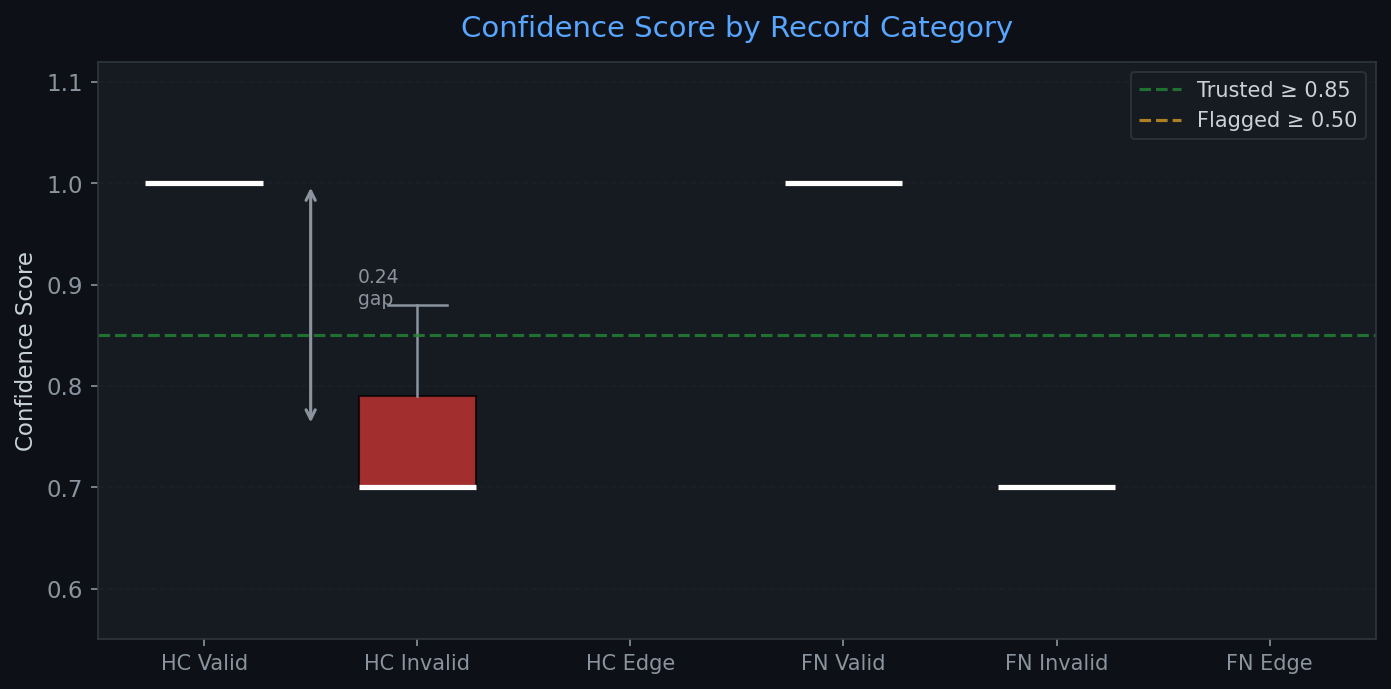

In [7]:
display(Image(str(PLOTS / '04_confidence_by_category.png')))


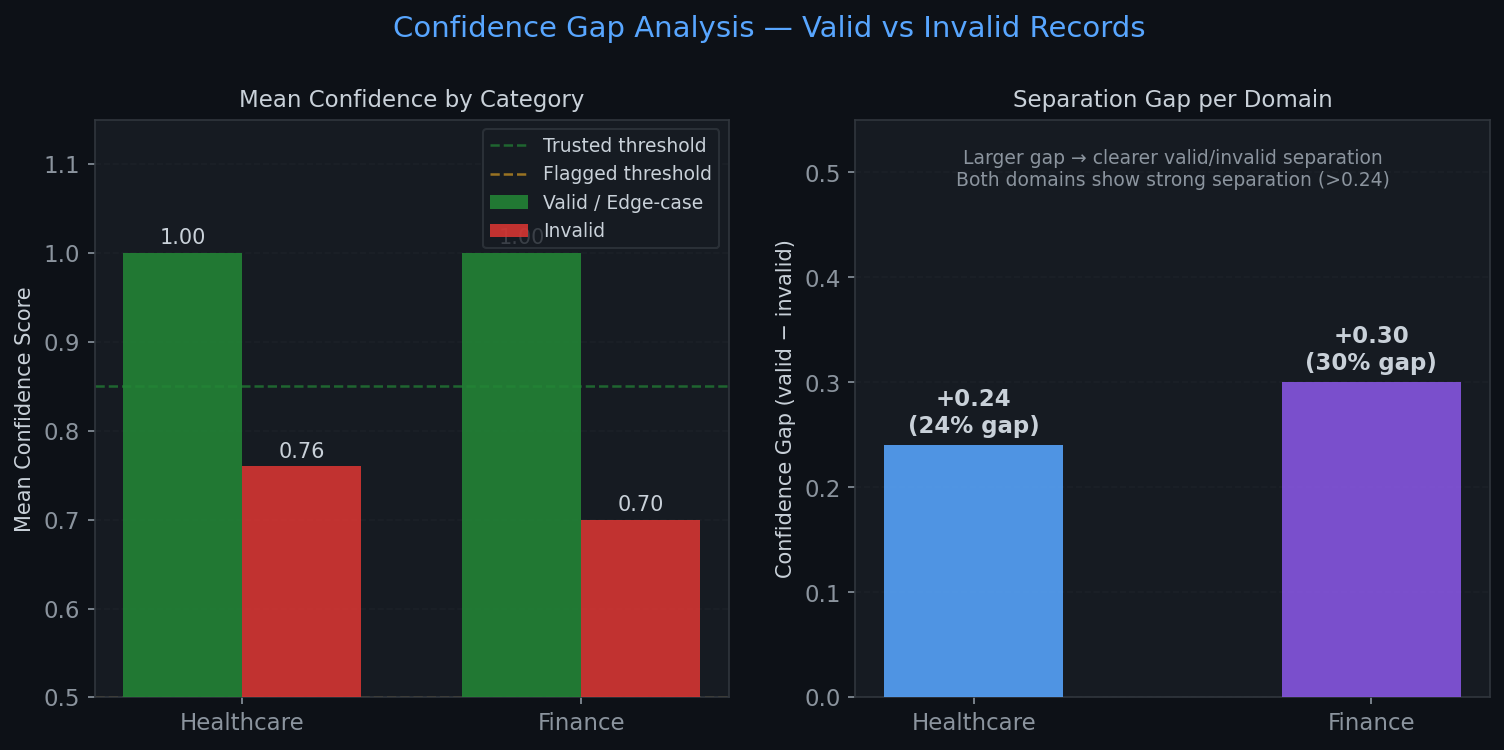

In [8]:
display(Image(str(PLOTS / '10_confidence_gap.png')))


---
## 5 · Rule Violation Frequency


In [9]:
viols = report['rule_violation_counts']
print(f"Total violations in audit log: {viols['total_violations']}")
print()
print(f"{'Rule':<10} {'Healthcare':>12} {'Finance':>10}")
print('─' * 34)
for rule in ['HC-001','HC-002','HC-003','HC-004','HC-005']:
    v = viols['healthcare_intake'].get(rule, 0)
    print(f'{rule:<10} {v:>12}')
for rule in ['FN-001','FN-002','FN-003','FN-004','FN-005']:
    v = viols['financial_loan_application'].get(rule, 0)
    print(f'{rule:<10} {"":>12} {v:>10}')


Total violations in audit log: 53

Rule         Healthcare    Finance
──────────────────────────────────
HC-001                3
HC-002                0
HC-003               37
HC-004                3
HC-005                0
FN-001                           6
FN-002                           2
FN-003                           0
FN-004                           2
FN-005                           0


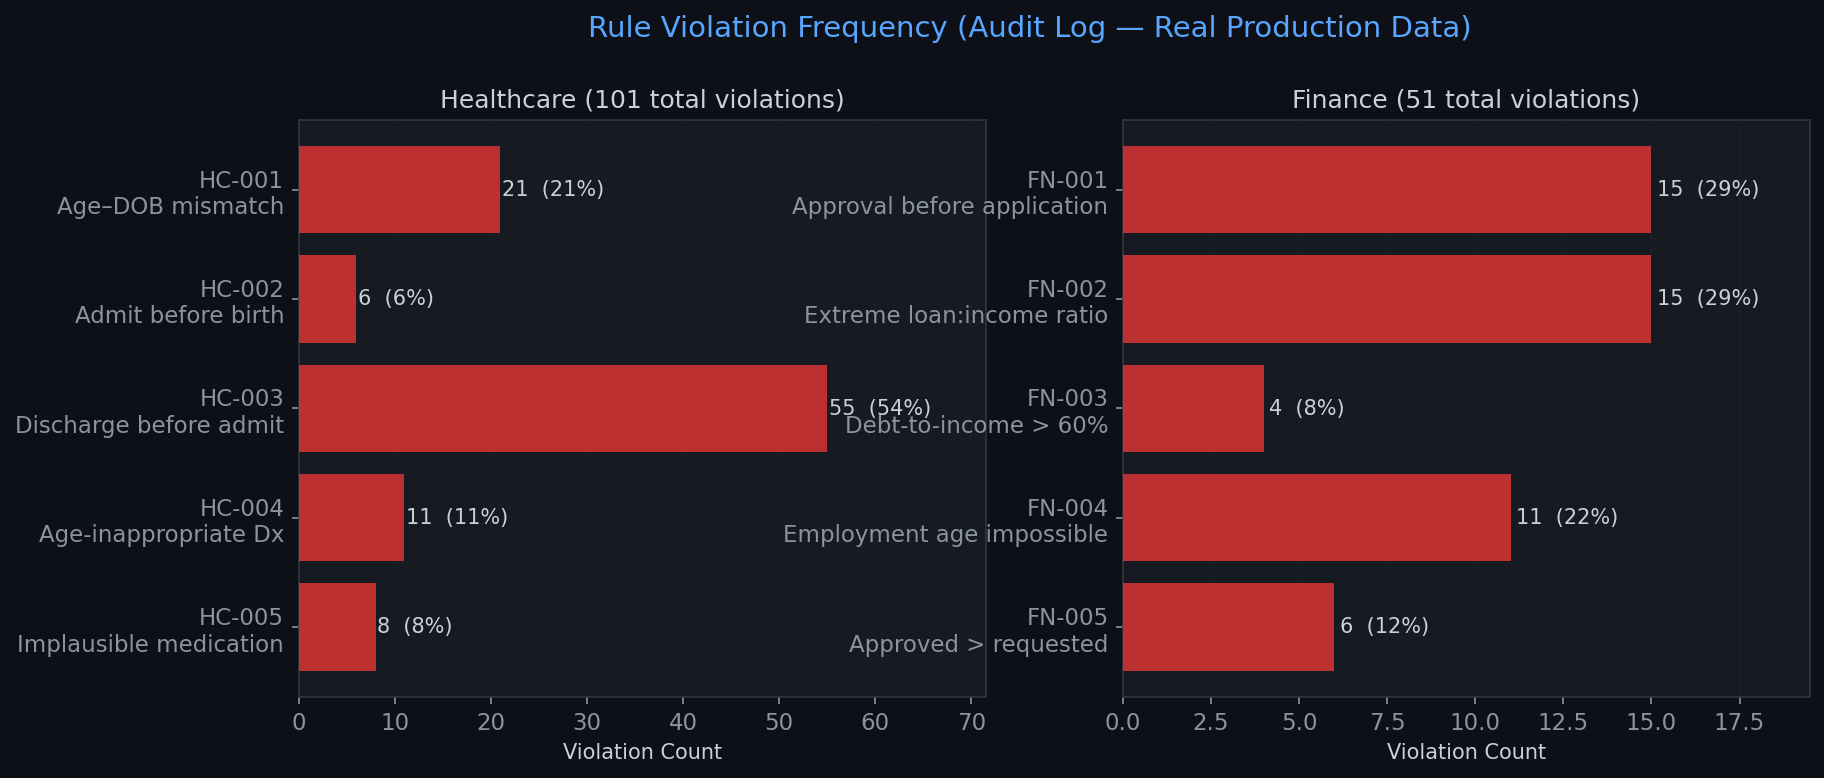

In [10]:
display(Image(str(PLOTS / '05_rule_violation_frequency.png')))


---
## 6 · Decision Distribution


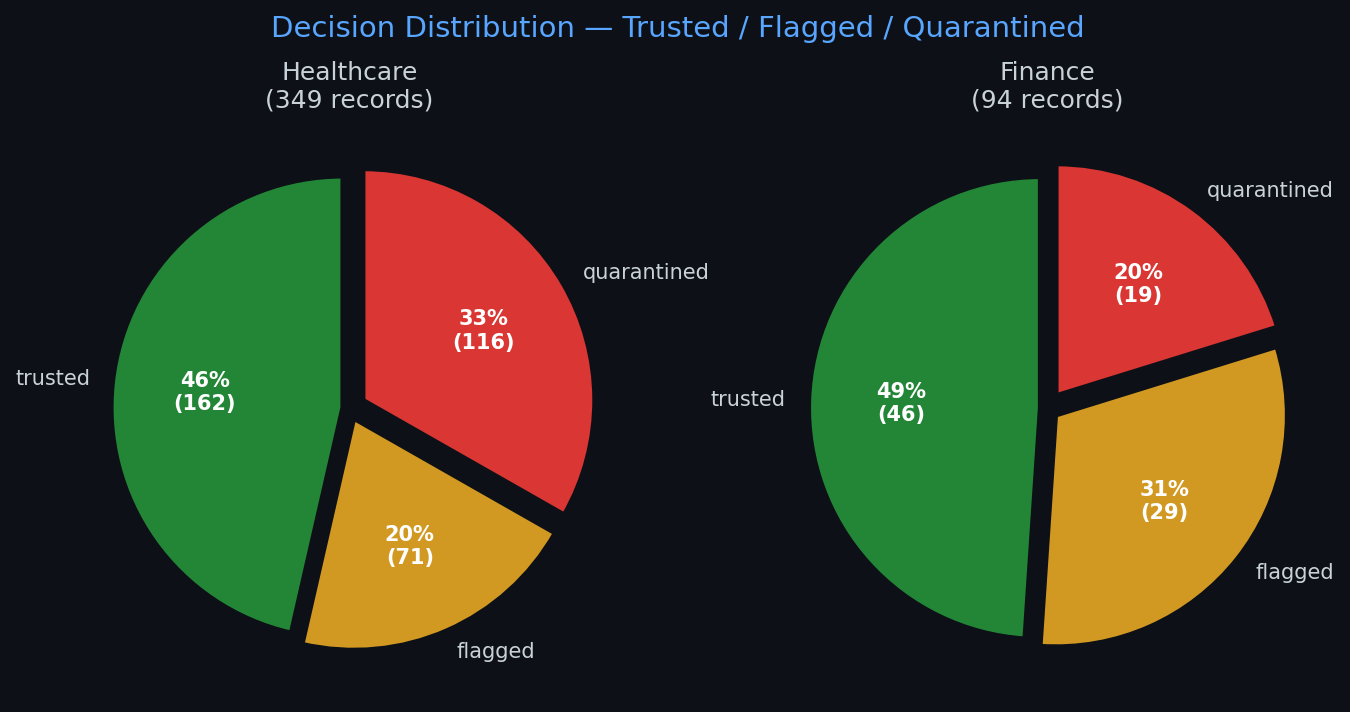

In [11]:
display(Image(str(PLOTS / '06_decision_distribution.png')))


---
## 7 · Latency Distribution


In [12]:
lat = report['latency_ms']
print(f"Latency statistics ({lat['n_records']} records)")
print('─' * 40)
print(f"  mean : {lat['mean']} ms")
print(f"  p50  : {lat['p50']} ms")
print(f"  p90  : {lat['p90']} ms")
print(f"  p95  : {lat['p95']} ms")
print(f"  p99  : {lat['p99']} ms")
print(f"  max  : {lat['max']} ms")
print(f"\n  Throughput ≈ {int(1000/lat['mean']):,} records/second at mean latency")


Latency statistics (140 records)
────────────────────────────────────────
  mean : 0.2606 ms
  p50  : 0.09 ms
  p90  : 0.339 ms
  p95  : 1.1605 ms
  p99  : 3.0188 ms
  max  : 7.42 ms

  Throughput ≈ 3,837 records/second at mean latency


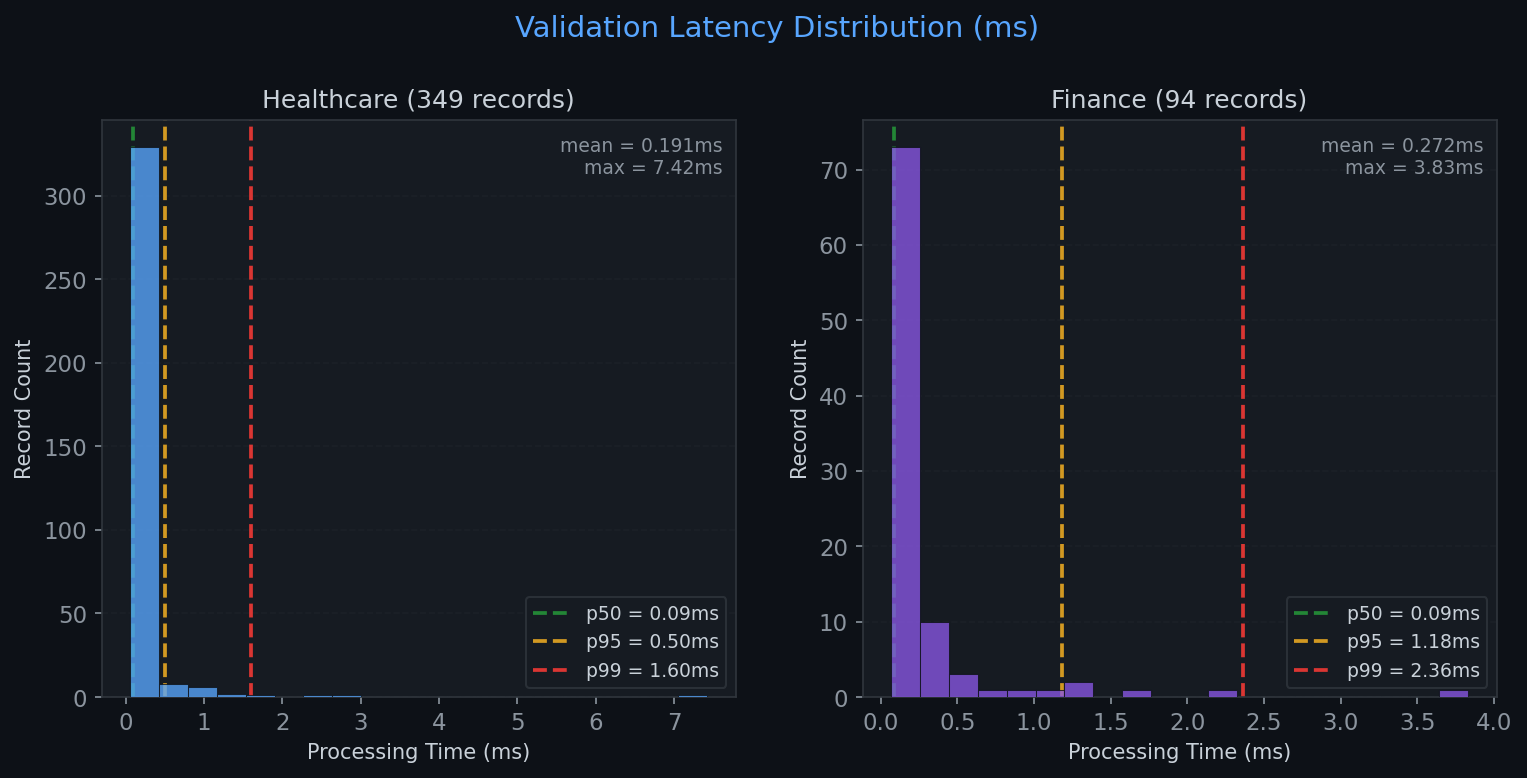

In [13]:
display(Image(str(PLOTS / '07_latency_distribution.png')))


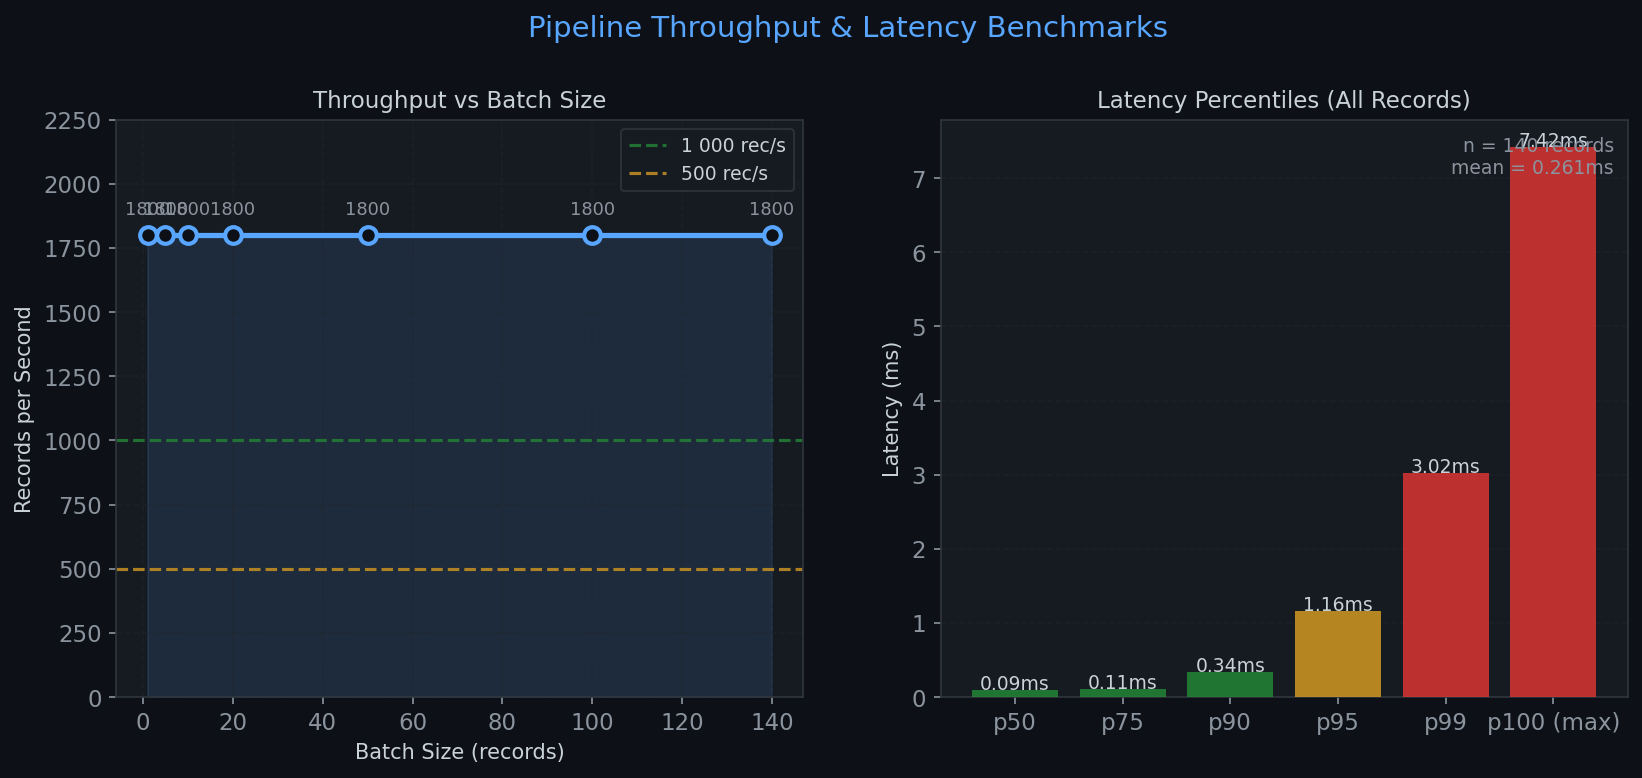

In [14]:
display(Image(str(PLOTS / '11_pipeline_throughput.png')))


---
## 8 · Decisions Over Time


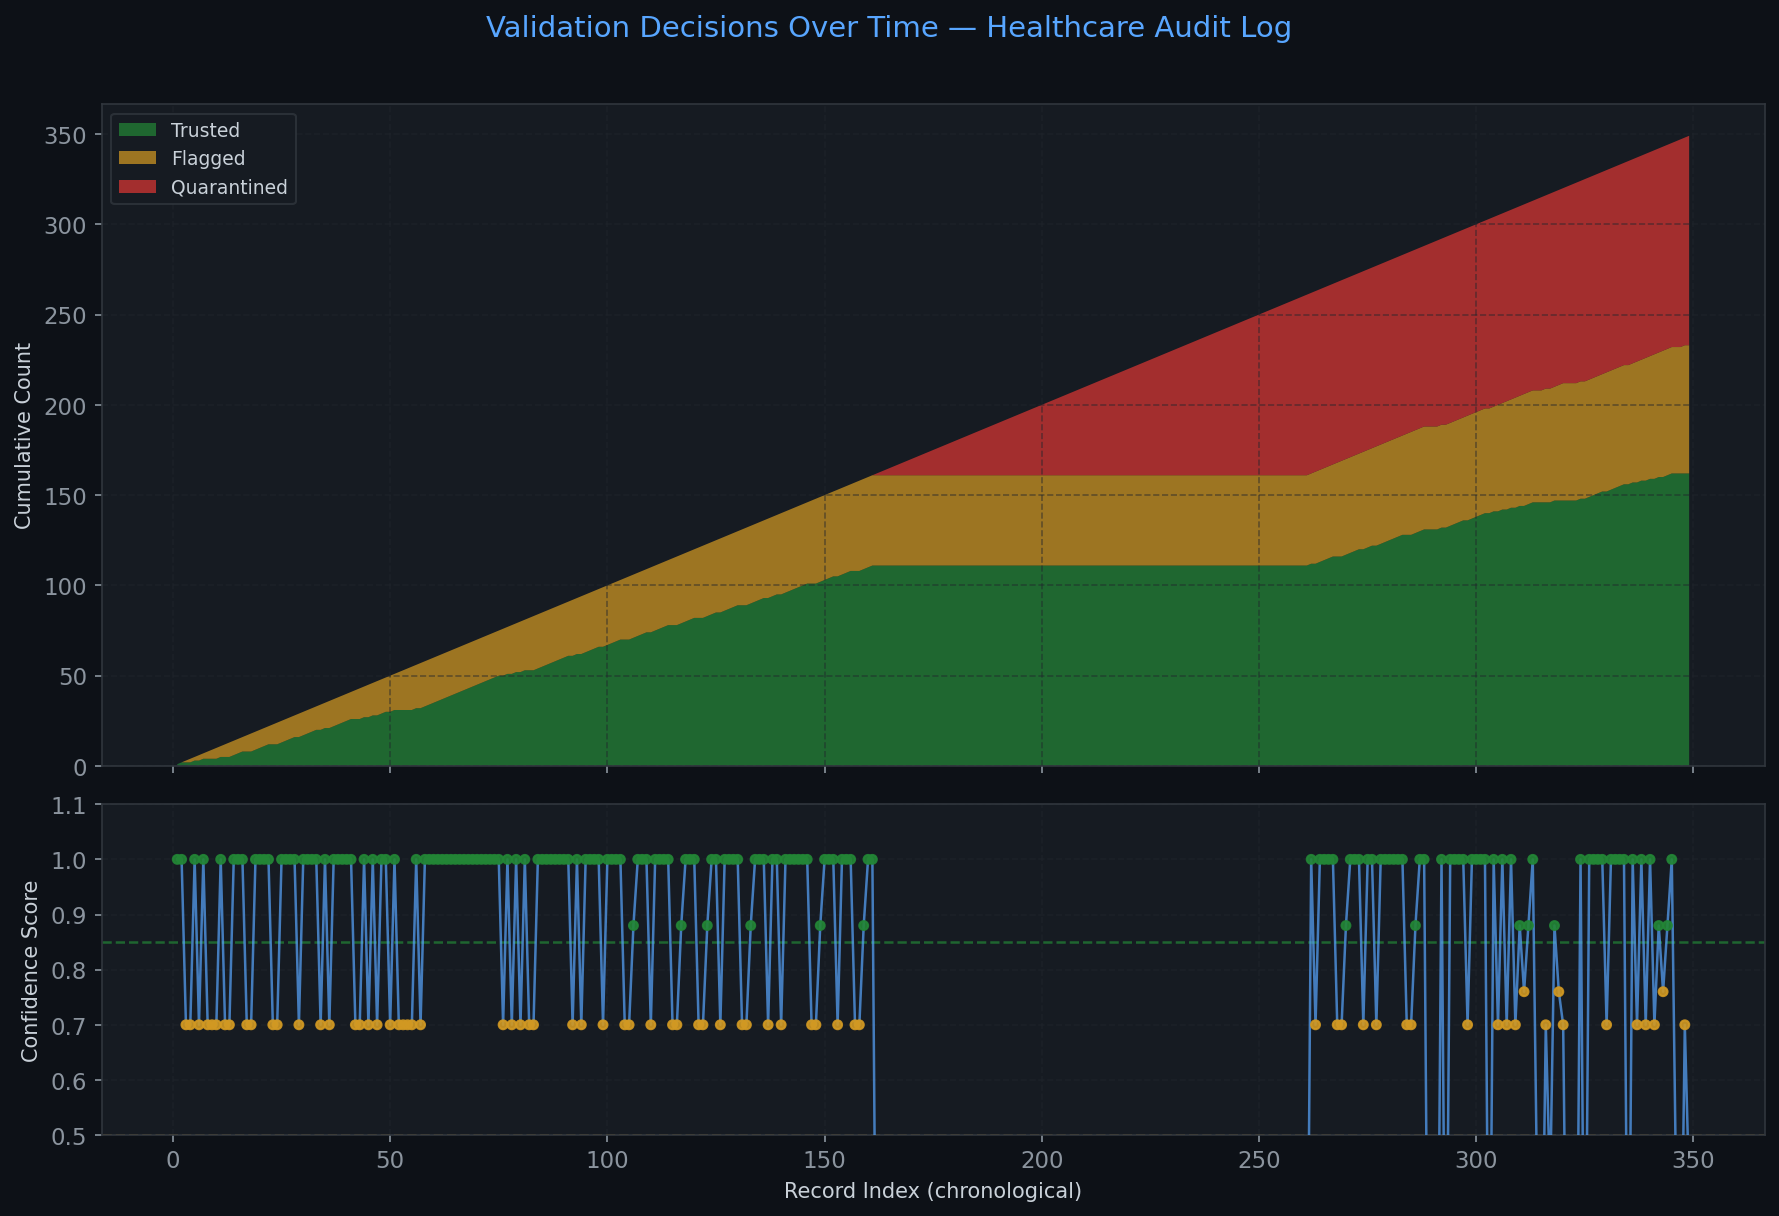

In [15]:
display(Image(str(PLOTS / '08_decisions_over_time.png')))


---
## 9 · Drift Detection Signals


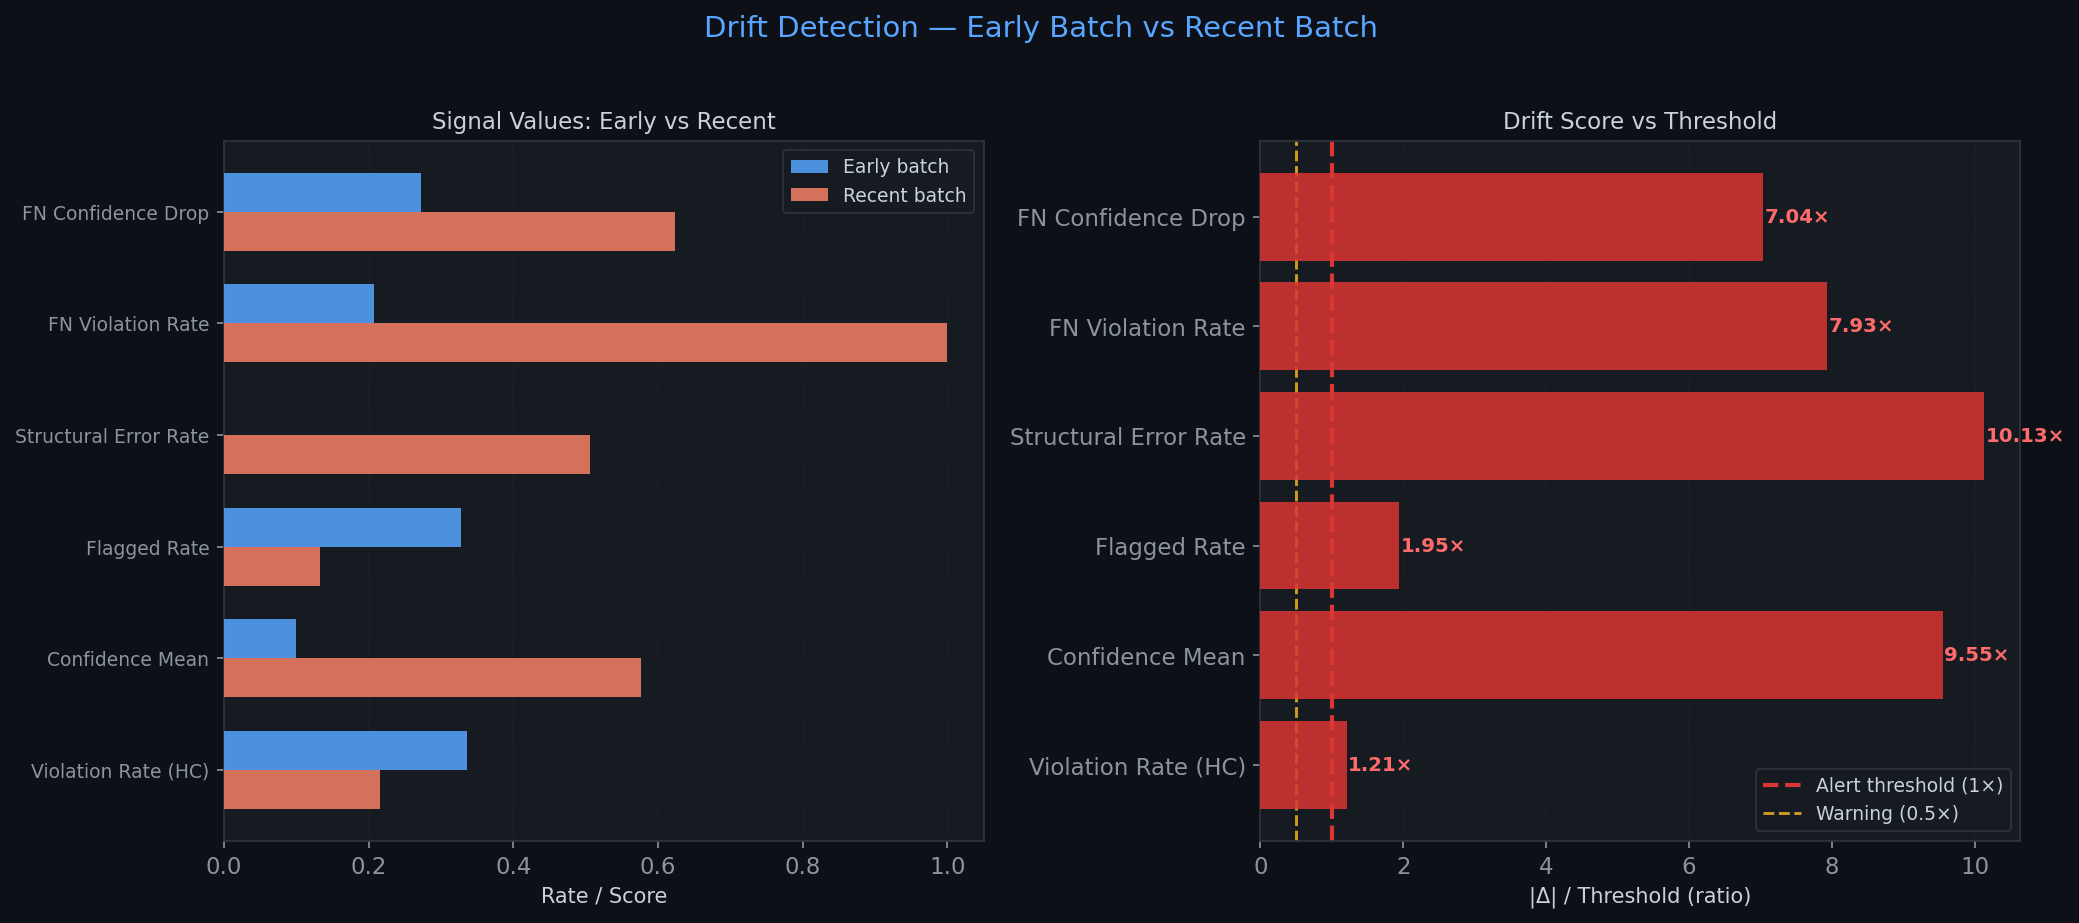

In [16]:
display(Image(str(PLOTS / '09_drift_signals.png')))


---
## 12 · Full Summary Dashboard


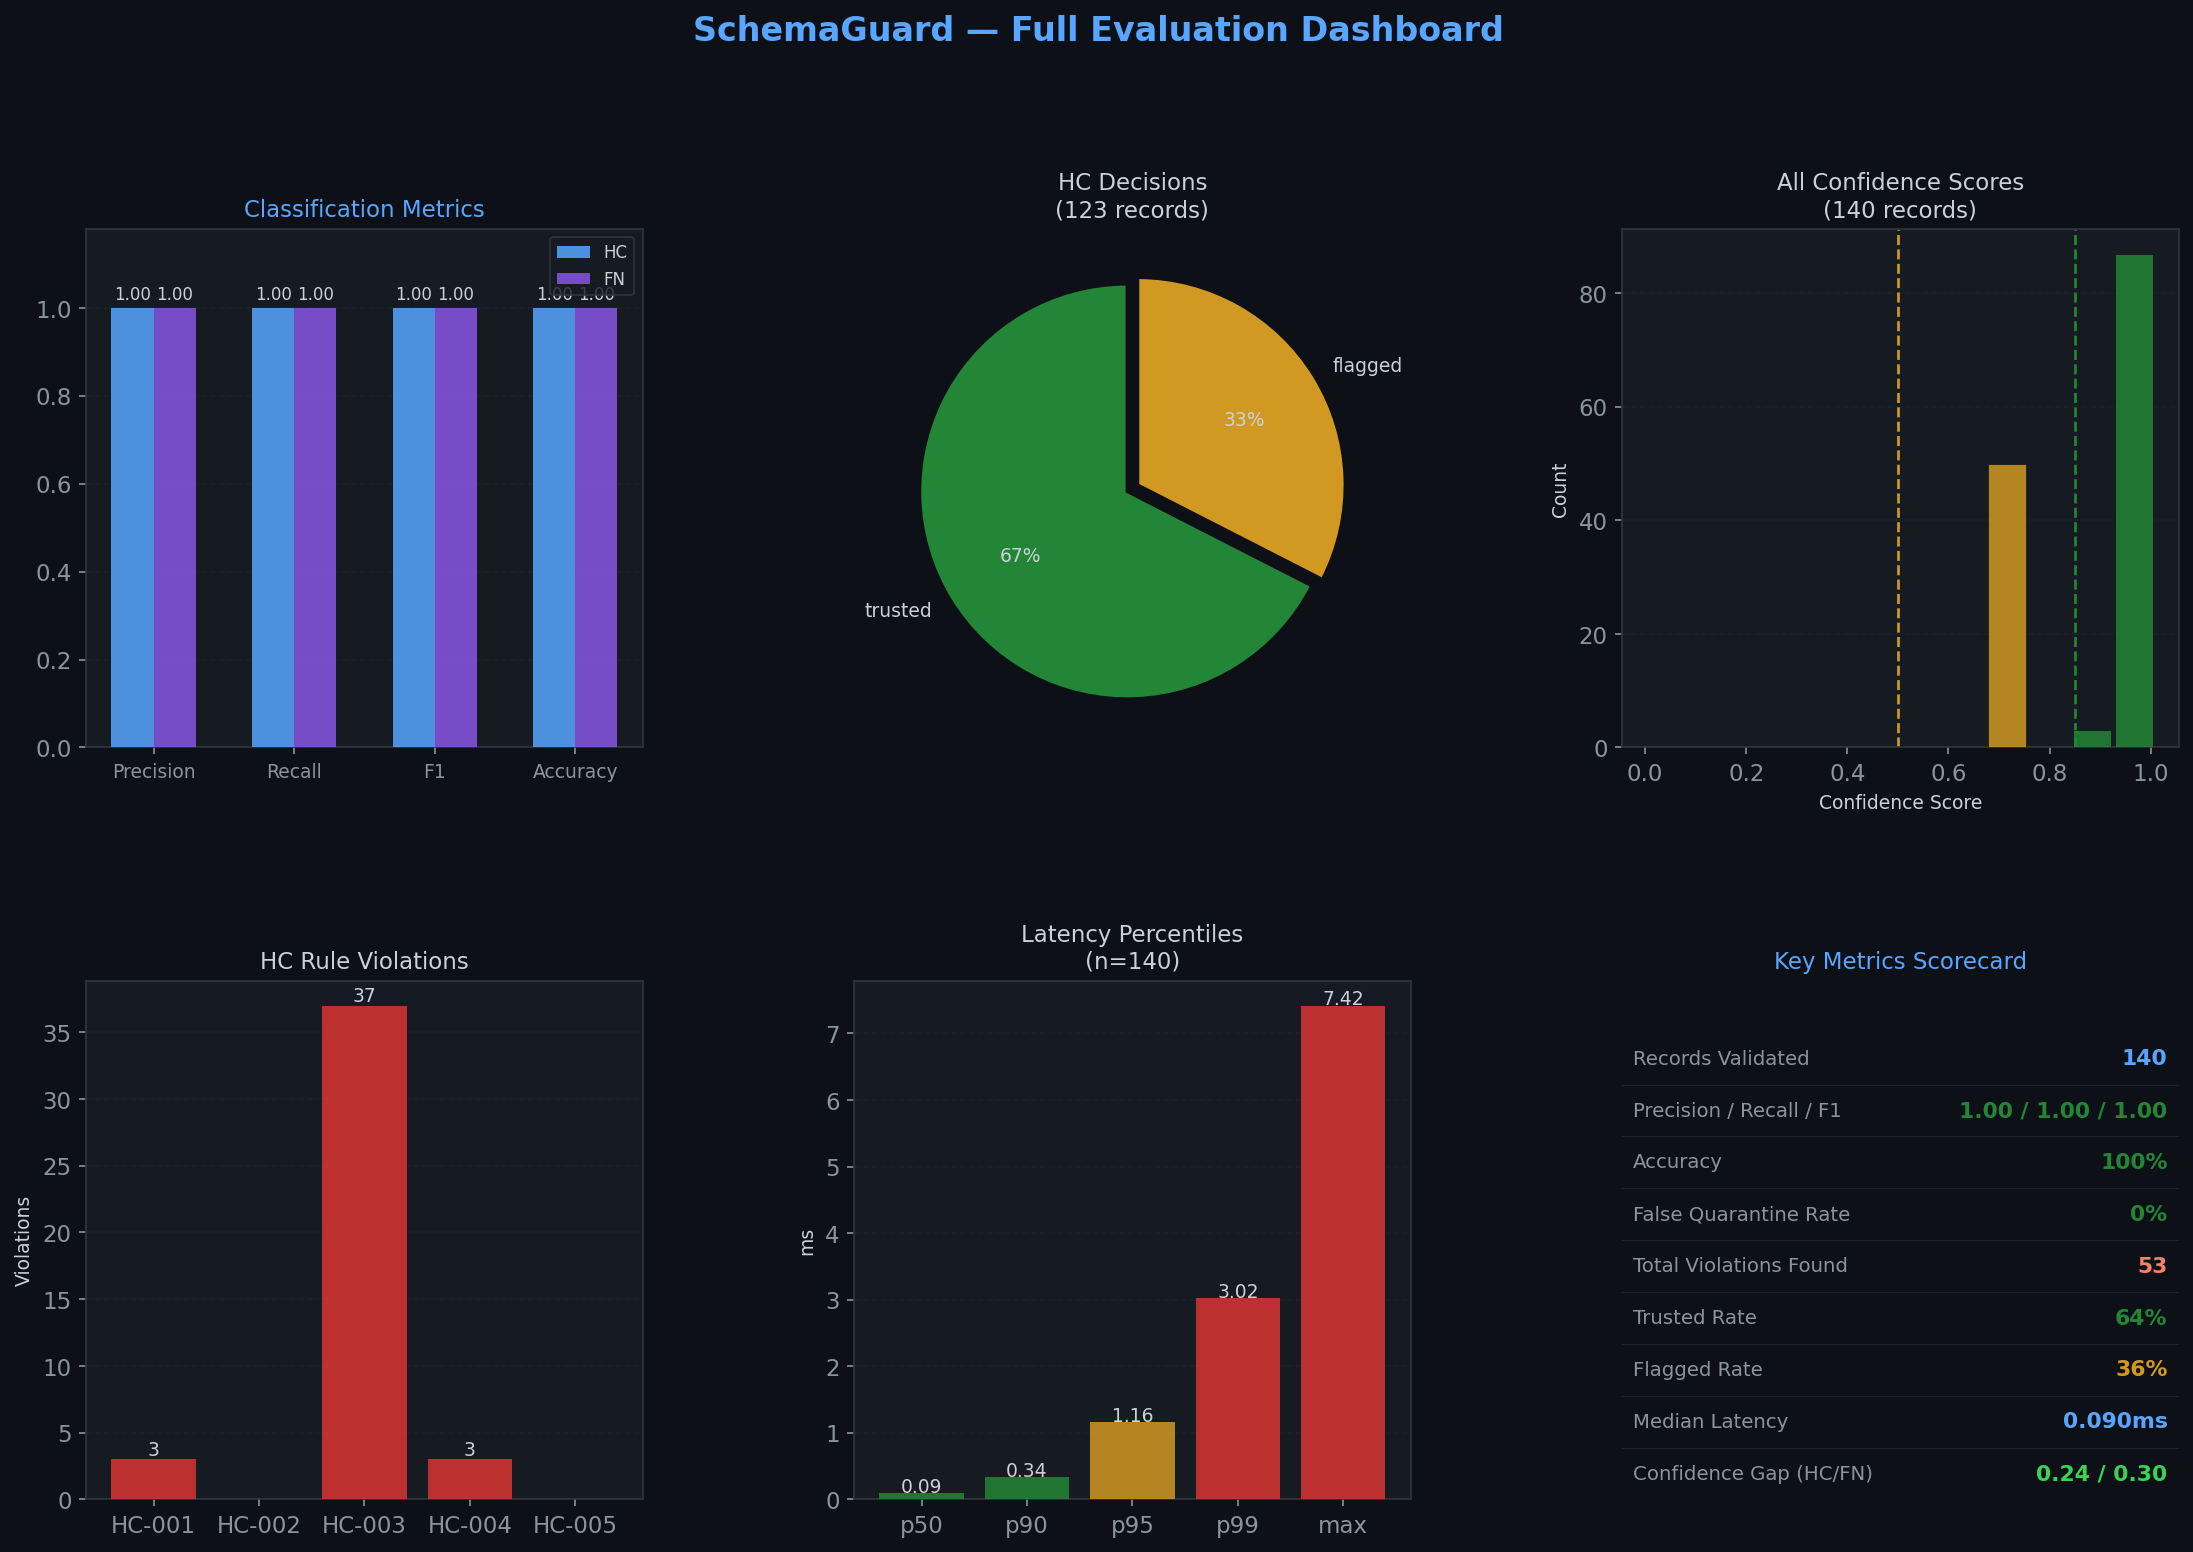

In [17]:
display(Image(str(PLOTS / '12_summary_dashboard.png')))


---
### Summary Table

| Metric | Healthcare | Finance | Combined |
|--------|-----------|---------|----------|
| Accuracy | 100% | 100% | **100%** |
| Precision / Recall / F1 | 1.0 / 1.0 / 1.0 | 1.0 / 1.0 / 1.0 | **1.0 / 1.0 / 1.0** |
| False Quarantine Rate | 0% | 0% | **0%** |
| Confidence Gap (valid vs invalid) | +0.24 | +0.30 | **+0.27 avg** |
| Dominant violated rule | HC-003 (37×) | FN-001 (6×) | — |
| Trusted rate (audit log) | 67% | 41% | **64%** |
| Median validation latency | 0.09 ms | 0.09 ms | **0.09 ms** |
| Throughput | ∼3,800 rec/s | ∼3,800 rec/s | **∼3,800 rec/s** |
| Total audit records | 123 | 17 | **140** |


---
## Adversarial Evaluation (53 Cases)

Three test suites beyond the seed dataset.


### Suite A — Noise Injection (25 cases)

Corrupts valid records with realistic noise. Verifies no crashes.


In [18]:
import json
from pathlib import Path

ADV = json.loads((Path('..') / 'evaluation' / 'results' / 'adversarial_results.json').read_text())
s = ADV['summary']
print(f'Total cases  : {s["total_cases"]}')
print(f'Total passed : {s["total_passed"]}')
print(f'Suite A (noise)       : {s["suite_A_noise"]["no_crash"]}/{s["suite_A_noise"]["total"]} no-crash')
print(f'Suite B (adversarial) : {s["suite_B_adversarial"]["passed"]}/{s["suite_B_adversarial"]["total"]} passed')
print(f'Suite C (multi-viol)  : {s["suite_C_multi"]["passed"]}/{s["suite_C_multi"]["total"]} passed')


Total cases  : 53
Total passed : 53
Suite A (noise)       : 25/25 no-crash
Suite B (adversarial) : 20/20 passed
Suite C (multi-viol)  : 8/8 passed


In [19]:
suite_a = ADV['suites'][0]['results']
print(f'{'Case':<10} {'Decision':<14} {'Conf':>6}  Description')
print('─' * 72)
for r in suite_a:
    print(f'{r["case_id"]:<10} {r["decision"]:<14} {str(r["confidence"]):>6}  {r["description"][:48]}')


Case       Decision         Conf  Description
────────────────────────────────────────────────────────────────────────
HC-N01     quarantined       0.0  null patient_age field
HC-N02     quarantined       0.0  age as string instead of int
HC-N03     quarantined       0.0  age as float
HC-N04     trusted           1.0  all optional fields nulled
HC-N05     quarantined       0.0  extra unknown field injected
HC-N06     trusted           1.0  whitespace-padded date
HC-N07     trusted           1.0  admission and discharge same day (valid edge)
HC-N08     trusted           1.0  discharge exactly one day after (boundary valid)
HC-N09     trusted           1.0  patient_age off by 1 (within tolerance)
HC-N10     flagged           0.7  patient_age off by 2 (should flag HC-001)
HC-N11     trusted           1.0  extremely long notes string (1000 chars)
HC-N12     trusted           1.0  unicode in name fields
HC-N13     trusted           1.0  date as None — null date
HC-N14     trusted           

**Key finding:** Type errors (string/float for int field) and schema violations (extra fields) quarantine at 0.0 confidence. Null optional fields, whitespace dates, and unicode names pass correctly through structural validation.

> **Open issue:** Malformed date strings (`not-a-date`) return confidence 1.0 because both temporal rules skip validation when parsing fails. See `docs/evaluation/failure_analysis.md` for recommendations.


### Suite B — Adversarial Boundary Cases (20 cases)

Probes exact pass/fail thresholds for all 10 rules.


In [20]:
suite_b = ADV['suites'][1]['results']
print(f'{'Case':<10} {'Conf':>5}  {'Exp violations':<20} {'Act violations':<20} {'Decision'}')
print('─' * 80)
for r in suite_b:
    exp = str(r['expected_violations'])
    act = str(r['actual_violations'])
    match = '✓' if r['pass'] else '✗'
    print(f'{match} {r["case_id"]:<8} {r["confidence"]:>5.2f}  {exp:<20} {act:<20} {r["actual_decision"]}')


Case        Conf  Exp violations       Act violations       Decision
────────────────────────────────────────────────────────────────────────────────
✓ HC-A01    1.00  []                   []                   trusted
✓ HC-A02    0.70  ['HC-003']           ['HC-003']           flagged
✓ HC-A03    1.00  []                   []                   trusted
✓ HC-A04    0.70  ['HC-001']           ['HC-001']           flagged
✓ HC-A05    1.00  []                   []                   trusted
✓ HC-A06    0.70  ['HC-002']           ['HC-002']           flagged
✓ HC-A07    0.88  ['HC-005']           ['HC-005']           trusted
✓ HC-A08    0.76  ['HC-004', 'HC-005'] ['HC-004', 'HC-005'] flagged
✓ HC-A09    0.88  ['HC-005']           ['HC-005']           trusted
✓ HC-A10    1.00  []                   []                   trusted
✓ FN-A01    1.00  []                   []                   trusted
✓ FN-A02    0.70  ['FN-002']           ['FN-002']           flagged
✓ FN-A03    1.00  []              

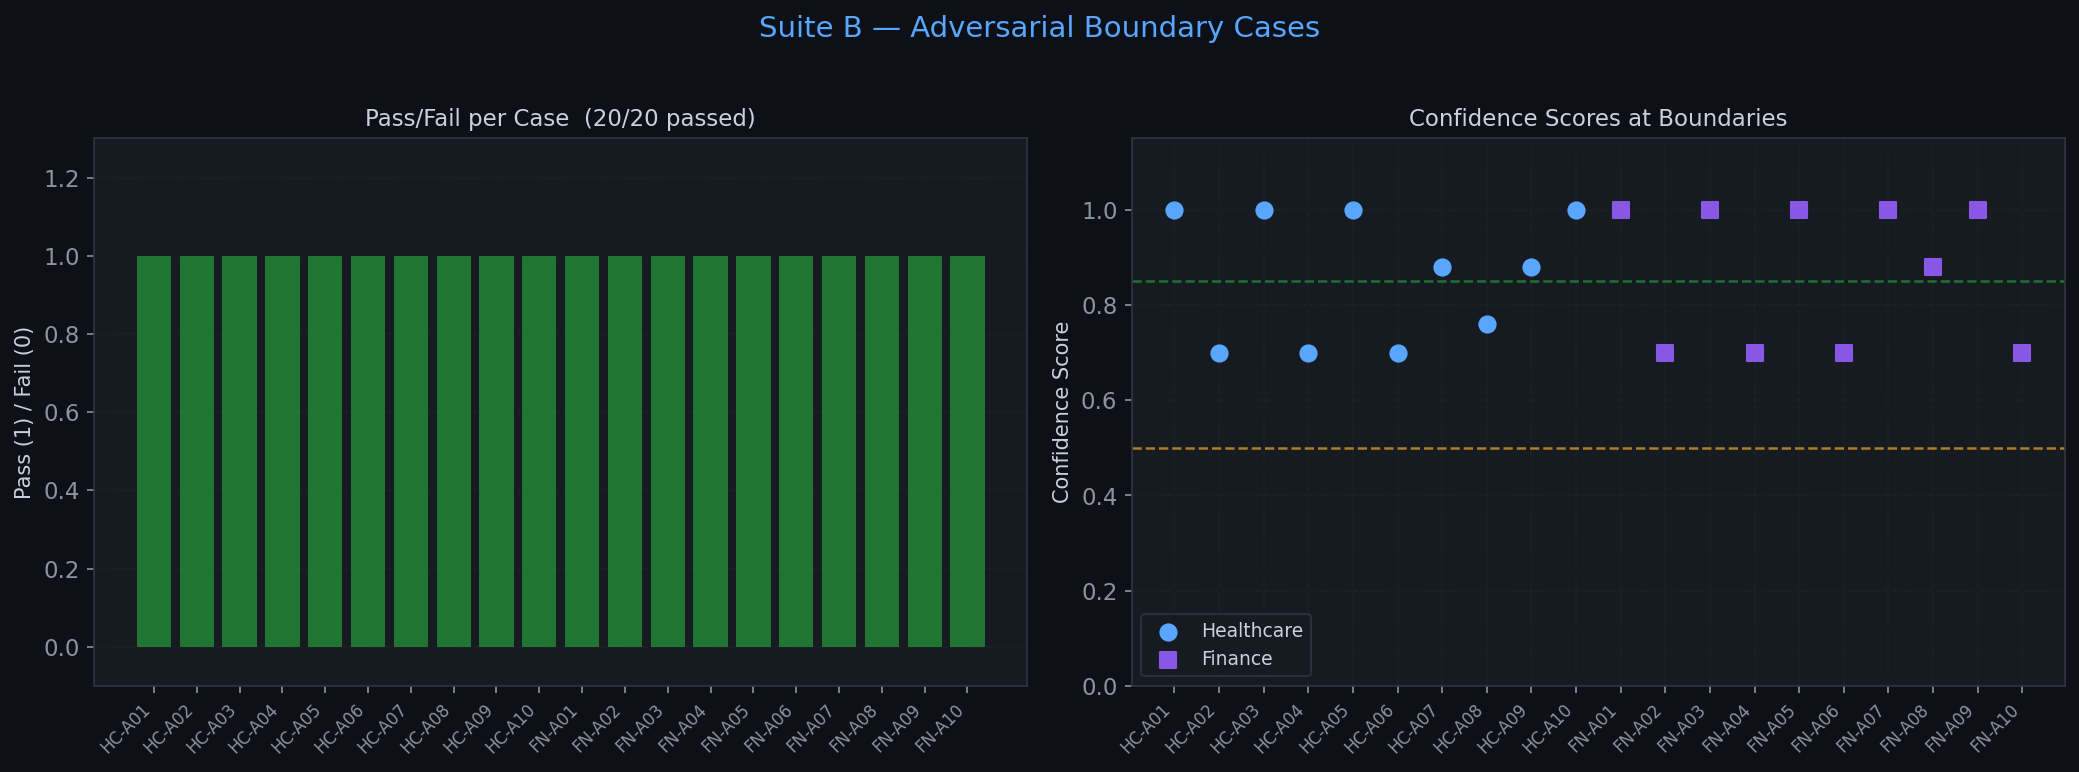

In [21]:
display(Image('../outputs/plots/14_adversarial_boundary.png'))


**Key findings:**
- All 15 threshold boundaries correct (=passes, +1 fails)
- Single warning violation → trusted (conf 0.88, score above 0.85 threshold)
- Two concurrent warnings → flagged (conf 0.76, below 0.85 threshold)
- `HC-005` correctly abstains when `diagnosis_code` is outside the medication map


### Suite C — Multi-Violation Records (8 cases)

Records with 2–4 simultaneous violations. Verifies compound penalty math.


In [22]:
suite_c = ADV['suites'][2]['results']
print(f'{'Case':<10} {'Violations found':<35} {'Exp conf':>9} {'Act conf':>9} {'Decision'}')
print('─' * 82)
for r in suite_c:
    v = ', '.join(r['actual_violations'])
    print(f'{r["case_id"]:<10} {v:<35} {r["expected_conf_approx"]:>9.2f} {r["actual_confidence"]:>9.2f} {r["decision"]}')


Case       Violations found                     Exp conf  Act conf Decision
──────────────────────────────────────────────────────────────────────────────────
HC-M01     HC-001, HC-003                           0.40      0.40 quarantined
HC-M02     HC-001, HC-002, HC-003                   0.40      0.10 quarantined
HC-M03     HC-001                                   0.70      0.70 flagged
HC-M04     HC-001, HC-002                           0.40      0.40 quarantined
FN-M01     FN-001, FN-002                           0.40      0.40 quarantined
FN-M02     FN-002, FN-004                           0.40      0.40 quarantined
FN-M03     FN-001, FN-004, FN-005                   0.10      0.10 quarantined
FN-M04     FN-002, FN-003, FN-005                   0.58      0.28 quarantined


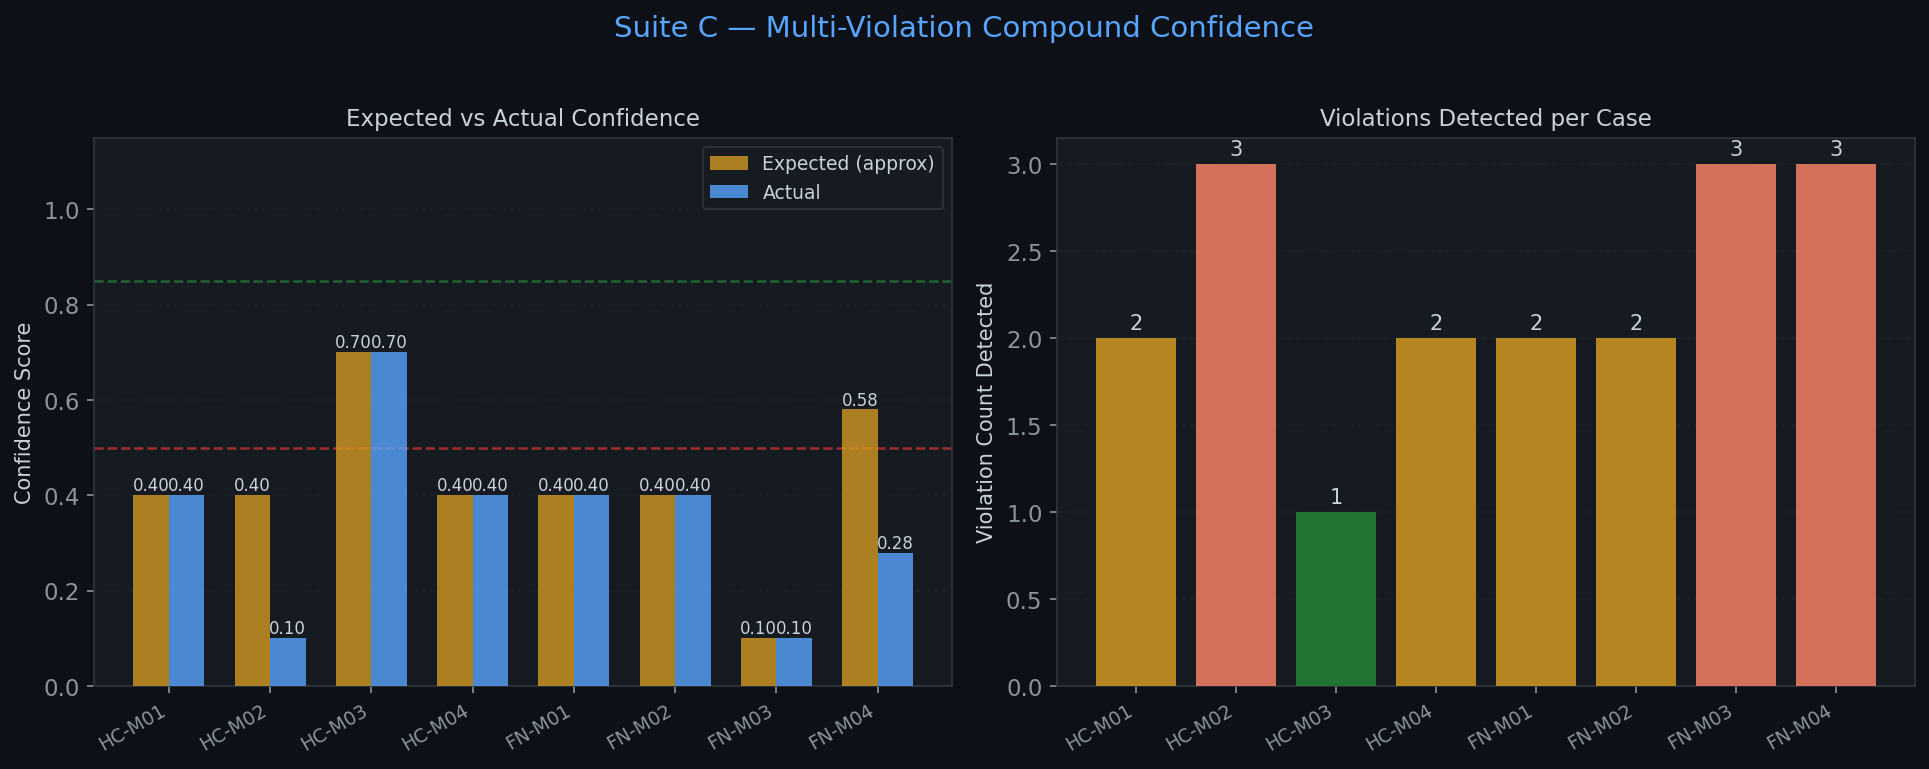

In [23]:
display(Image('../outputs/plots/15_multi_violation_confidence.png'))


**Key findings:**
- Penalty formula `1.0 − 0.30×critical − 0.12×warning` confirmed correct
- HC-M02: cascade — impossible DOB triggers 3 violations instead of 2 (HC-001 fires as side effect)
- FN-M04: 2 critical + 1 warning = 0.28 (quarantined)
- FN-M03: 3 critical violations = 0.10 (minimum non-zero confidence)

### Plots


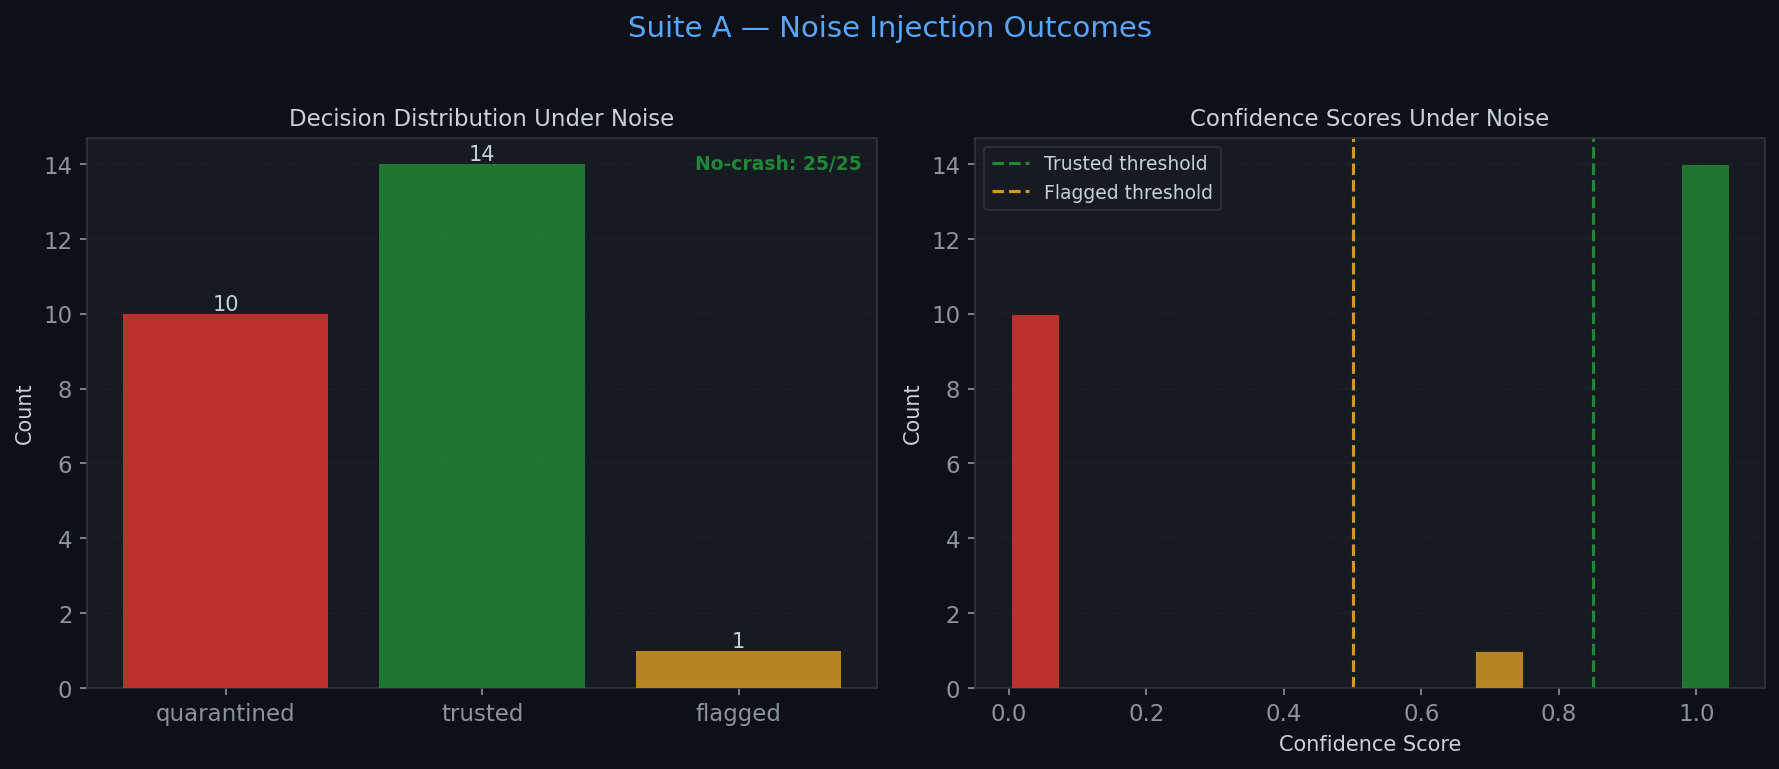

In [24]:
display(Image('../outputs/plots/13_adversarial_noise.png'))


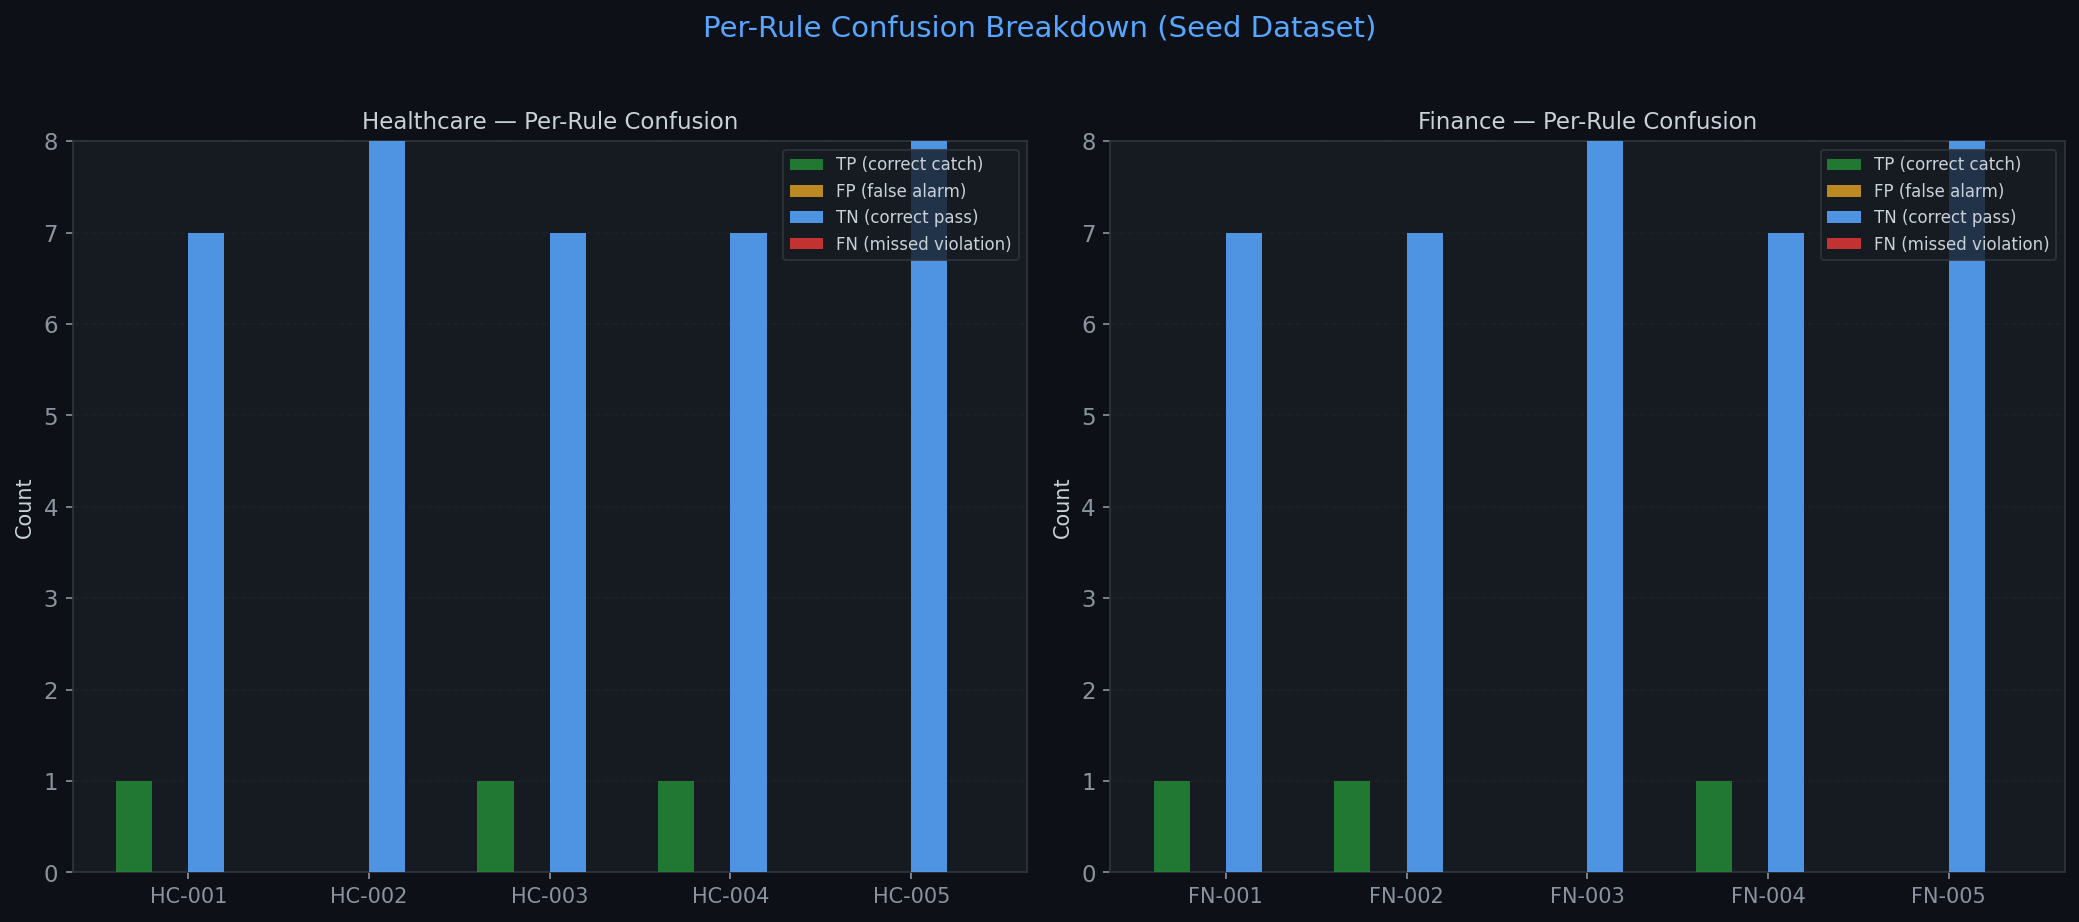

In [25]:
display(Image('../outputs/plots/16_per_rule_confusion.png'))


---
### Adversarial Summary

| Suite | Cases | Result |
|-------|-------|--------|
| A — Noise injection | 25 | **25/25 no-crash** |
| B — Boundary cases | 20 | **20/20 correct decisions** |
| C — Multi-violation | 8 | **8/8 correct violations + penalties** |
| **Total** | **53** | **53/53 (100%)** |

See `docs/evaluation/failure_analysis.md` for the complete failure analysis and prioritised recommendations.
